<a href="https://colab.research.google.com/github/nguyenvuonghongvy/TH_DeepLearning/blob/main/labs04_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
from keras import regularizers
encoding_dim = 32
input_img = keras.Input(shape=(784,))
#them l1
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)
de_coded = layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_img, de_coded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                # 50 => 100
                epochs=100,
                batch_size=256, verbose = 1,
                shuffle = True,
                validation_data = (x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.0143 - loss: 0.6550 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.3739 - 

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


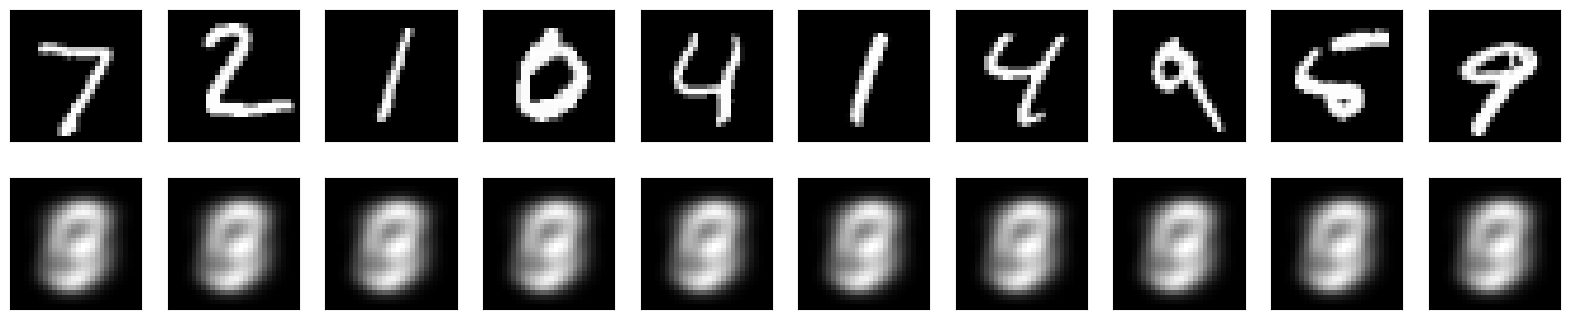

In [ ]:
import matplotlib.pyplot as plt
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2, n, i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

**BÀI TẬP 1**

### Loading and Preprocessing CIFAR10

In [ ]:
from keras.datasets import cifar10
import numpy as np

# Load CIFAR10 data
(x_train_cifar, _), (x_test_cifar, _) = cifar10.load_data()

# Normalize and reshape
x_train_cifar = x_train_cifar.astype('float32') / 255.
x_test_cifar = x_test_cifar.astype('float32') / 255.

# For a simple Dense autoencoder, we flatten the 32x32x3 images
input_shape_cifar = np.prod(x_train_cifar.shape[1:])
x_train_flat = x_train_cifar.reshape((len(x_train_cifar), input_shape_cifar))
x_test_flat = x_test_cifar.reshape((len(x_test_cifar), input_shape_cifar))

print(f"Train shape: {x_train_flat.shape}")
print(f"Test shape: {x_test_flat.shape}")

Train shape: (50000, 3072)
Test shape: (10000, 3072)


### Defining the CIFAR10 Autoencoder Model

In [ ]:
from keras import layers, models

# Ensure units is a standard Python int to avoid ValueError
encoding_dim_cifar = 128
units_output = int(input_shape_cifar)

input_img_cifar = keras.Input(shape=(units_output,))

# Encoder
encoded_cifar = layers.Dense(encoding_dim_cifar, activation='relu')(input_img_cifar)

# Decoder
decoded_cifar = layers.Dense(units_output, activation='sigmoid')(encoded_cifar)

# Models
autoencoder_cifar = keras.Model(input_img_cifar, decoded_cifar)
autoencoder_cifar.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_cifar.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3072)           │       396,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,632 (3.01 MB)

 Trainable params: 789,632 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder_cifar.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.6388 - val_loss: 0.6193
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.6124 - val_loss: 0.6083
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.6037 - val_loss: 0.6011
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.5983 - val_loss: 0.5958
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.5939 - val_loss: 0.5946
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 0.5899 - val_loss: 0.5950
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.5877 - val_loss: 0.5871
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.5863 - val_loss: 0.5867
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.5854 - val_loss: 0.5870
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - loss: 0.5847 - val_loss: 0.5853
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.5842 - val_loss: 0.5849
Epoch 12/50
196/196 ━━━━━━━━━━

### Visualizing CIFAR10 Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


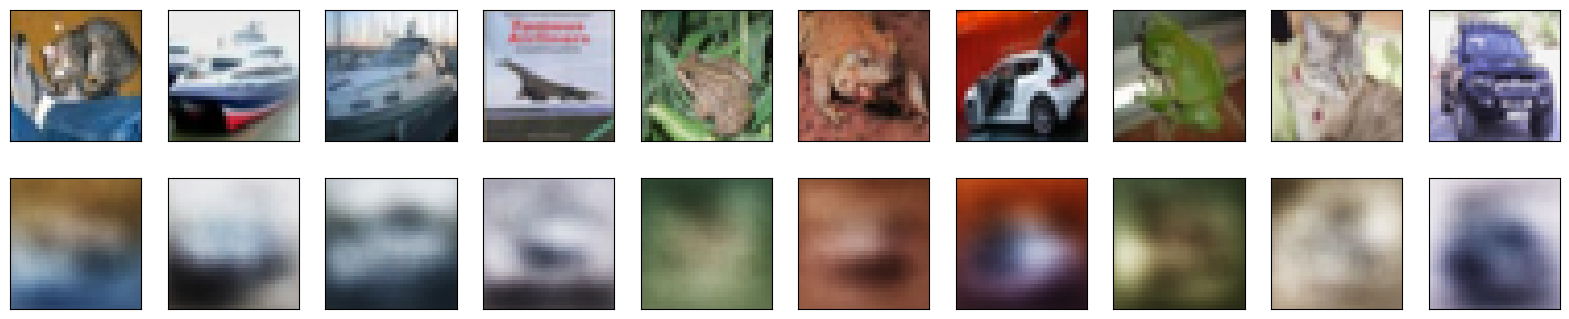

In [ ]:
decoded_imgs_cifar = autoencoder_cifar.predict(x_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cifar[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_cifar[i].reshape(32, 32, 3))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()